In [20]:
import numpy as np
from pathlib import Path

# Choose the parent folder and run name.
# Expected layout for this experiment:
# exp_data/max_grad_norm/1.0/seed5/cifar10_half_cnn_eps2.0/losses_in.npy
# exp_data/max_grad_norm/1.0/seed6/cifar10_half_cnn_eps2.0/losses_out.npy
results_root = Path("exp_data/max_grad_norm/1.0")
run_name = "cifar10_half_cnn_eps10.0"
seeds = [5, 6, 7, 8, 9]

all_losses_in = []
all_losses_out = []
emp_losses = []

for seed in seeds:
    base = results_root / f"seed{seed}" / run_name
    in_path = base / "losses_in.npy"
    out_path = base / "losses_out.npy"

    if not in_path.exists() or not out_path.exists():
        raise FileNotFoundError(f"Missing losses for seed {seed}: {base}")

    seed_losses_in = np.load(in_path).reshape(-1)
    seed_losses_out = np.load(out_path).reshape(-1)

    print(f"seed {seed}: losses_in {seed_losses_in.shape}, losses_out {seed_losses_out.shape}")

    all_losses_in.append(seed_losses_in)
    all_losses_out.append(seed_losses_out)
    emp_losses.append(np.mean(np.concatenate([seed_losses_in, seed_losses_out])))

losses_in = np.concatenate(all_losses_in)
losses_out = np.concatenate(all_losses_out)

print("\nConcatenated across seeds 5-9")
print("losses_in:", losses_in.shape, losses_in.dtype)
print("losses_out:", losses_out.shape, losses_out.dtype)
print("mean empirical loss across the five seeds:", float(np.mean(emp_losses)))
print(losses_in)
print(losses_out)

seed 5: losses_in (100,), losses_out (100,)
seed 6: losses_in (100,), losses_out (100,)
seed 7: losses_in (100,), losses_out (100,)
seed 8: losses_in (100,), losses_out (100,)
seed 9: losses_in (100,), losses_out (100,)

Concatenated across seeds 5-9
losses_in: (500,) float64
losses_out: (500,) float64
mean empirical loss across the five seeds: -5.476931371688843
[-6.02807045 -6.4859066  -6.46710014 -6.32061148 -6.04540014 -6.08034325
 -6.03393936 -6.04467964 -6.02290154 -6.40555429 -5.69704151 -6.34386683
 -5.8665843  -5.78454208 -6.24440479 -6.37998152 -6.21963978 -5.55947065
 -5.71169424 -5.57700586 -6.22411919 -4.81523323 -6.00016451 -6.18086147
 -5.51991892 -5.96722031 -5.46712923 -6.02102518 -6.21480608 -6.57819223
 -5.93950272 -6.31113291 -6.03536272 -5.58004093 -5.21533632 -6.16713905
 -6.33502388 -5.90989685 -6.28284645 -6.10350227 -6.18563318 -6.69287014
 -6.05635071 -6.40025759 -5.94602299 -5.56457424 -5.92624378 -5.48836517
 -5.867136   -6.25407553 -5.97908115 -6.15286875 -

losses_in_clean: (500,)
losses_out_clean: (500,)


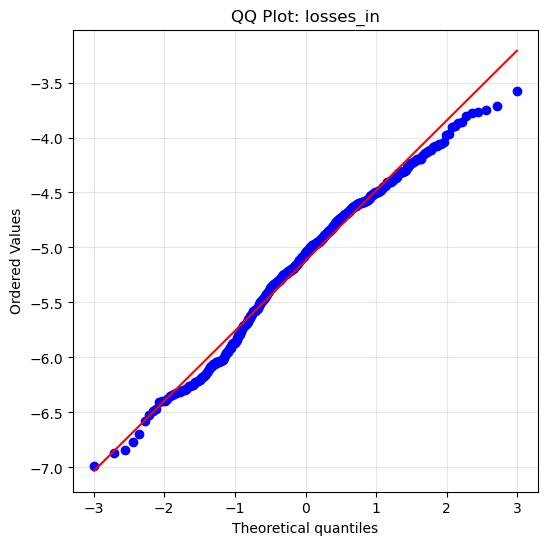

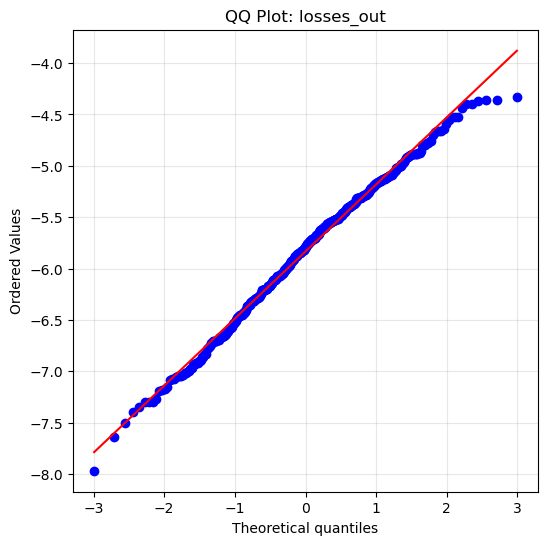

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Optional: remove non-finite values just in case
losses_in_clean = losses_in #[np.isfinite(losses_in)]
losses_out_clean = losses_out# [np.isfinite(losses_out)]

print("losses_in_clean:", losses_in_clean.shape)
print("losses_out_clean:", losses_out_clean.shape)

# QQ plot for losses_in
plt.figure(figsize=(6, 6))
stats.probplot(losses_in_clean, dist="norm", plot=plt)
plt.title("QQ Plot: losses_in")
plt.grid(True, alpha=0.3)
plt.show()

# QQ plot for losses_out
plt.figure(figsize=(6, 6))
stats.probplot(losses_out_clean, dist="norm", plot=plt)
plt.title("QQ Plot: losses_out")
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
import numpy as np
from scipy.stats import shapiro

# Clean in case there are NaN or inf values
losses_in_clean = losses_in[np.isfinite(losses_in)]
losses_out_clean = losses_out[np.isfinite(losses_out)]

# Shapiro-Wilk tests
shapiro_in = shapiro(losses_in_clean)
shapiro_out = shapiro(losses_out_clean)

print("Shapiro-Wilk test for losses_in")
print(f"  W statistic: {shapiro_in.statistic:.6f}")
print(f"  p-value:     {shapiro_in.pvalue:.6e}")

print("\nShapiro-Wilk test for losses_out")
print(f"  W statistic: {shapiro_out.statistic:.6f}")
print(f"  p-value:     {shapiro_out.pvalue:.6e}")

alpha = 0.05

print("\nInterpretation at alpha = 0.05:")
if shapiro_in.pvalue > alpha:
    print("  losses_in: fail to reject normality")
else:
    print("  losses_in: reject normality")

if shapiro_out.pvalue > alpha:
    print("  losses_out: fail to reject normality")
else:
    print("  losses_out: reject normality")

Shapiro-Wilk test for losses_in
  W statistic: 0.985309
  p-value:     6.131431e-05

Shapiro-Wilk test for losses_out
  W statistic: 0.993694
  p-value:     3.531574e-02

Interpretation at alpha = 0.05:
  losses_in: reject normality
  losses_out: reject normality
